In [10]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Final data set.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Month,Region,ASM,ASO,Distributor_Type,Super_code,Super_name,Distributor_Code,Distributor_Name,Distributor_Area,...,Outlet_Location,Route_ID,Route_Name,Category,Subcategory,SKU_Code,SKU_Name,Pieces,KG/Litre,Sales in Rs.
0,Dec'25,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,"22.54107519,88.37638814",9278698.0,"Centralkolkata,Rajakatra Market",Oils,Ricebran Oil,HTRBO1027,Ricebran Oil 825 gm Pch,6,4.95,786.00
1,Dec'25,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,"22.54107519,88.37638814",9278698.0,"Centralkolkata,Rajakatra Market",Oils,Ricebran Oil,HTRBO1031,Ricebran Oil 730 gm Pch,12,8.76,1437.36
2,Dec'25,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,"22.54107519,88.37638814",9278698.0,"Centralkolkata,Rajakatra Market",Oils,Sunflower Oil,HTSFO1018,Sunflower Oil 825 gm Pch,6,4.95,877.50
3,Dec'25,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,"22.54107519,88.37638814",9278698.0,"Centralkolkata,Rajakatra Market",Oils,Sunflower Oil,HTSFO1030,Sunflower Oil 780 gm Pch (12 pc),12,9.36,1693.68
4,Dec'25,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,"22.58214300,88.35074090",927.0,Rajakatra Market,Oils,Ricebran Oil,HTRBO1031,Ricebran Oil 730 gm Pch,6,4.38,718.68


In [11]:
print(df.info())
print(df.describe(include='all'))
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214880 entries, 0 to 214879
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Month             214880 non-null  object 
 1   Region            214880 non-null  object 
 2   ASM               214880 non-null  object 
 3   ASO               214880 non-null  object 
 4   Distributor_Type  214880 non-null  object 
 5   Super_code        214880 non-null  object 
 6   Super_name        214880 non-null  object 
 7   Distributor_Code  214880 non-null  int64  
 8   Distributor_Name  214880 non-null  object 
 9   Distributor_Area  214880 non-null  object 
 10  User_Login        214880 non-null  object 
 11  User_Name         214880 non-null  object 
 12  Outlet_ID         214880 non-null  int64  
 13  Outlet_Class      214880 non-null  object 
 14  Outlet_Types      214880 non-null  object 
 15  Outlet_Location   214880 non-null  object 
 16  Route_ID          21

In [12]:
# Drop rows with any missing values, as it's only one row based on the previous isnull().sum() output
df.dropna(inplace=True)

# Verify that missing values have been handled
print("Missing values after dropping rows:")
print(df.isnull().sum())

# Display the shape of the DataFrame after dropping rows
print(f"\nDataFrame shape after dropping rows: {df.shape}")

Missing values after dropping rows:
Month               0
Region              0
ASM                 0
ASO                 0
Distributor_Type    0
Super_code          0
Super_name          0
Distributor_Code    0
Distributor_Name    0
Distributor_Area    0
User_Login          0
User_Name           0
Outlet_ID           0
Outlet_Class        0
Outlet_Types        0
Outlet_Location     0
Route_ID            0
Route_Name          0
Category            0
Subcategory         0
SKU_Code            0
SKU_Name            0
Pieces              0
KG/Litre            0
Sales in Rs.        0
dtype: int64

DataFrame shape after dropping rows: (214880, 25)


In [13]:
# Convert 'Month' column to datetime objects.
# Assuming '25' refers to 2025, '26' to 2026.
# Add '20' prefix to the year for correct parsing.
df['Month'] = df['Month'].apply(lambda x: x.replace("'", "20"))
df['Month'] = pd.to_datetime(df['Month'], format='%b%Y')

# Display the updated info to show the new 'Month' dtype
print(df.info())
print(df['Month'].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214880 entries, 0 to 214879
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Month             214880 non-null  datetime64[ns]
 1   Region            214880 non-null  object        
 2   ASM               214880 non-null  object        
 3   ASO               214880 non-null  object        
 4   Distributor_Type  214880 non-null  object        
 5   Super_code        214880 non-null  object        
 6   Super_name        214880 non-null  object        
 7   Distributor_Code  214880 non-null  int64         
 8   Distributor_Name  214880 non-null  object        
 9   Distributor_Area  214880 non-null  object        
 10  User_Login        214880 non-null  object        
 11  User_Name         214880 non-null  object        
 12  Outlet_ID         214880 non-null  int64         
 13  Outlet_Class      214880 non-null  object        
 14  Outl

In [14]:
# Extract 'YearMonth' for potential time-based aggregation
df['YearMonth'] = df['Month'].dt.to_period('M')

# Aggregate data to create features for segmentation at the 'Outlet' level
outlet_features = df.groupby('Outlet_ID').agg(
    Total_Sales=('Sales in Rs.', 'sum'),
    Unique_Products=('SKU_Code', 'nunique'),
    Avg_Sales_Per_Product=('Sales in Rs.', lambda x: x.sum() / x.count()),
    Total_Pieces_Sold=('Pieces', 'sum'),
    Total_KGLitre_Sold=('KG/Litre', 'sum')
).reset_index()

print("Outlet Features DataFrame Head:")
display(outlet_features.head())
print("\nOutlet Features DataFrame Info:")
print(outlet_features.info())

Outlet Features DataFrame Head:


,Outlet_ID,Total_Sales,Unique_Products,Avg_Sales_Per_Product,Total_Pieces_Sold,Total_KGLitre_Sold
0,389,5527.75,7,789.678571,62,30.34
1,390,57860.80,32,890.166154,812,439.79
2,391,24856.08,18,994.243200,287,182.26
3,392,541528.62,34,9845.974909,4086,4917.74
4,393,73738.73,39,996.469324,1214,485.75



Outlet Features DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9679 entries, 0 to 9678
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Outlet_ID              9679 non-null   int64  
 1   Total_Sales            9679 non-null   float64
 2   Unique_Products        9679 non-null   int64  
 3   Avg_Sales_Per_Product  9679 non-null   float64
 4   Total_Pieces_Sold      9679 non-null   int64  
 5   Total_KGLitre_Sold     9679 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 453.8 KB
None


In [15]:
# Get the unique Outlet_Class for each Outlet_ID and convert to a Series
outlet_class_series = df[['Outlet_ID', 'Outlet_Class']].drop_duplicates().set_index('Outlet_ID')['Outlet_Class']

# Map the Outlet_Class to the outlet_features DataFrame
outlet_features['Outlet_Class'] = outlet_features['Outlet_ID'].map(outlet_class_series)

print("Outlet Features DataFrame Head with corrected Outlet_Class:")
display(outlet_features.head())
print("\nOutlet Features DataFrame Info with corrected Outlet_Class:")
print(outlet_features.info())

Outlet Features DataFrame Head with corrected Outlet_Class:


,Outlet_ID,Total_Sales,Unique_Products,Avg_Sales_Per_Product,Total_Pieces_Sold,Total_KGLitre_Sold,Outlet_Class
0,389,5527.75,7,789.678571,62,30.34,D
1,390,57860.80,32,890.166154,812,439.79,D
2,391,24856.08,18,994.243200,287,182.26,A
3,392,541528.62,34,9845.974909,4086,4917.74,D
4,393,73738.73,39,996.469324,1214,485.75,D



Outlet Features DataFrame Info with corrected Outlet_Class:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9679 entries, 0 to 9678
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Outlet_ID              9679 non-null   int64  
 1   Total_Sales            9679 non-null   float64
 2   Unique_Products        9679 non-null   int64  
 3   Avg_Sales_Per_Product  9679 non-null   float64
 4   Total_Pieces_Sold      9679 non-null   int64  
 5   Total_KGLitre_Sold     9679 non-null   float64
 6   Outlet_Class           9679 non-null   object 
dtypes: float64(3), int64(3), object(1)
memory usage: 529.4+ KB
None


### Feature Scaling for Clustering

Before applying clustering algorithms, it's essential to scale the numerical features to ensure that all features contribute equally to the distance calculations. Features with larger values might otherwise dominate the clustering results. I will use `StandardScaler` to transform the data so that it has a mean of 0 and a standard deviation of 1.

In [16]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features to scale
numerical_features = ['Total_Sales', 'Unique_Products', 'Avg_Sales_Per_Product', 'Total_Pieces_Sold', 'Total_KGLitre_Sold']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical features
outlet_features_scaled = outlet_features.copy()
outlet_features_scaled[numerical_features] = scaler.fit_transform(outlet_features_scaled[numerical_features])

print("Scaled Outlet Features DataFrame Head:")
display(outlet_features_scaled.head())
print("\nScaled Outlet Features DataFrame Info:")
print(outlet_features_scaled.info())

Scaled Outlet Features DataFrame Head:


,Outlet_ID,Total_Sales,Unique_Products,Avg_Sales_Per_Product,Total_Pieces_Sold,Total_KGLitre_Sold,Outlet_Class
0,389,-0.131313,-0.817644,-0.091493,-0.166614,-0.099418,D
1,390,-0.041918,2.179256,-0.088540,0.014206,-0.015616,D
2,391,-0.098296,0.500992,-0.085482,-0.112368,-0.068325,A
3,392,0.784273,2.419008,0.174628,0.803548,0.900888,D
4,393,-0.014796,3.018388,-0.085416,0.111126,-0.006209,D



Scaled Outlet Features DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9679 entries, 0 to 9678
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Outlet_ID              9679 non-null   int64  
 1   Total_Sales            9679 non-null   float64
 2   Unique_Products        9679 non-null   float64
 3   Avg_Sales_Per_Product  9679 non-null   float64
 4   Total_Pieces_Sold      9679 non-null   float64
 5   Total_KGLitre_Sold     9679 non-null   float64
 6   Outlet_Class           9679 non-null   object 
dtypes: float64(5), int64(1), object(1)
memory usage: 529.4+ KB
None


### Determining the Optimal Number of Clusters (Elbow Method)

To find the optimal number of clusters for K-Means, I will use the Elbow method. This method involves computing the Within-Cluster Sum of Squares (WCSS) for a range of k values (number of clusters) and plotting the results. The 'elbow' point in the plot, where the rate of decrease in WCSS significantly changes, suggests the optimal number of clusters.

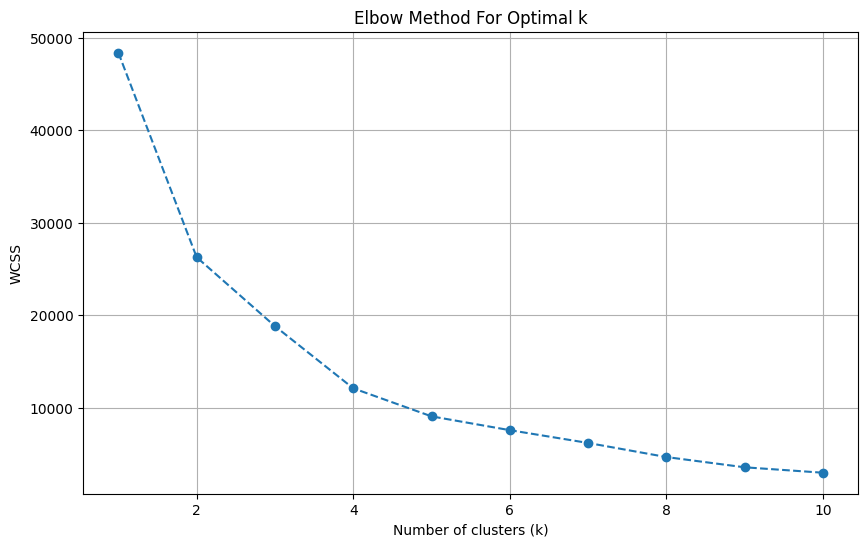

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Drop non-numerical columns for clustering
X = outlet_features_scaled.drop(columns=['Outlet_ID', 'Outlet_Class'])

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

### Applying K-Means Clustering

Based on the user's request for 4 segments, I will proceed with applying K-Means clustering with `n_clusters=4` to the scaled outlet features. The cluster labels will then be added back to the `outlet_features_scaled` DataFrame for further analysis.

In [18]:
# Apply K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
outlet_features_scaled['Cluster'] = kmeans.fit_predict(X)

print("Outlet Features DataFrame with Cluster Labels:")
display(outlet_features_scaled.head())

Outlet Features DataFrame with Cluster Labels:


,Outlet_ID,Total_Sales,Unique_Products,Avg_Sales_Per_Product,Total_Pieces_Sold,Total_KGLitre_Sold,Outlet_Class,Cluster
0,389,-0.131313,-0.817644,-0.091493,-0.166614,-0.099418,D,1
1,390,-0.041918,2.179256,-0.088540,0.014206,-0.015616,D,0
2,391,-0.098296,0.500992,-0.085482,-0.112368,-0.068325,A,0
3,392,0.784273,2.419008,0.174628,0.803548,0.900888,D,0
4,393,-0.014796,3.018388,-0.085416,0.111126,-0.006209,D,0


### Analyzing the Clusters

Now that we have the clusters, let's analyze their characteristics to understand what defines each segment. We will calculate the mean of the original (unscaled) numerical features for each cluster and also look at the distribution of `Outlet_Class` within each cluster.

In [19]:
# Merge cluster labels back to the original (unscaled) outlet_features for easier interpretation
outlet_features['Cluster'] = outlet_features_scaled['Cluster']

# Calculate the mean of original features for each cluster
cluster_analysis = outlet_features.groupby('Cluster')[numerical_features].mean()
print("Mean of features per cluster (unscaled):")
display(cluster_analysis)

# Analyze Outlet_Class distribution within each cluster
print("\nOutlet_Class distribution per cluster:")
cluster_outlet_class_distribution = outlet_features.groupby('Cluster')['Outlet_Class'].value_counts(normalize=True).unstack(fill_value=0)
display(cluster_outlet_class_distribution)

Mean of features per cluster (unscaled):


,Total_Sales,Unique_Products,Avg_Sales_Per_Product,Total_Pieces_Sold,Total_KGLitre_Sold
Cluster,,,,,
0,6.335095e+04,22.378506,1586.169180,733.258978,396.927565
1,2.561611e+04,8.153233,2025.988032,257.081470,155.417426
2,1.401669e+07,11.300000,837754.001285,98390.000000,108569.891000
3,3.152058e+06,14.682353,137210.426226,23819.211765,17630.949294



Outlet_Class distribution per cluster:


Outlet_Class,(blank),A,B,C,D
Cluster,,,,,
0,0.000000,0.117693,0.173526,0.435387,0.273394
1,0.000173,0.068816,0.105218,0.381002,0.444791
2,0.000000,0.800000,0.000000,0.100000,0.100000
3,0.000000,0.835294,0.035294,0.035294,0.094118


### Visualizing the Clusters

To better understand the separation of the clusters, we can visualize them using a pair plot or by examining specific feature relationships.

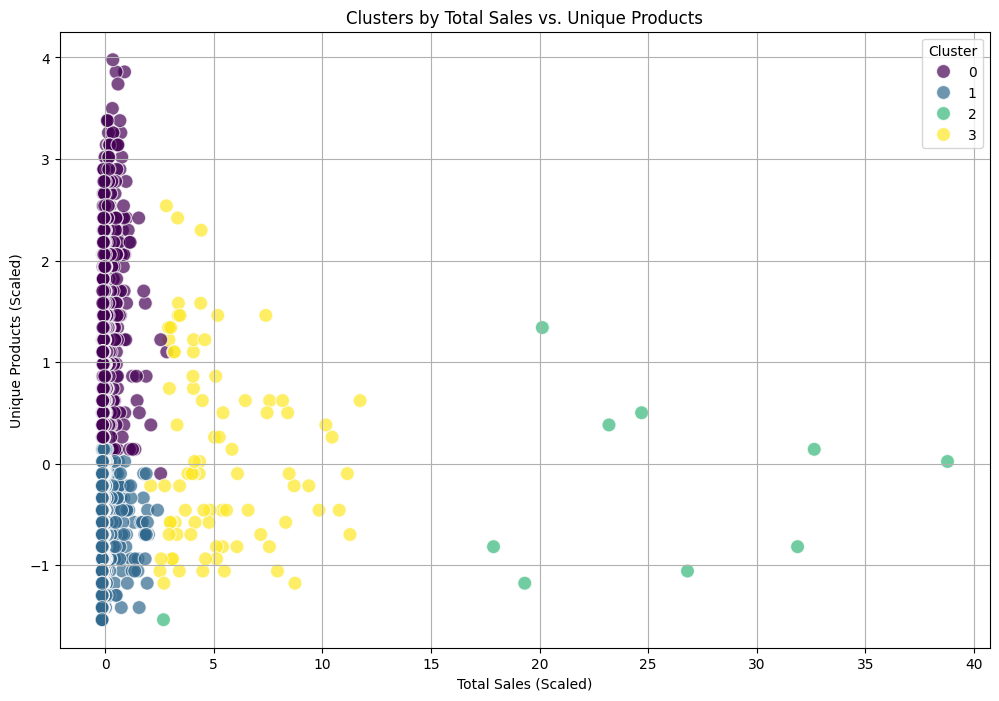

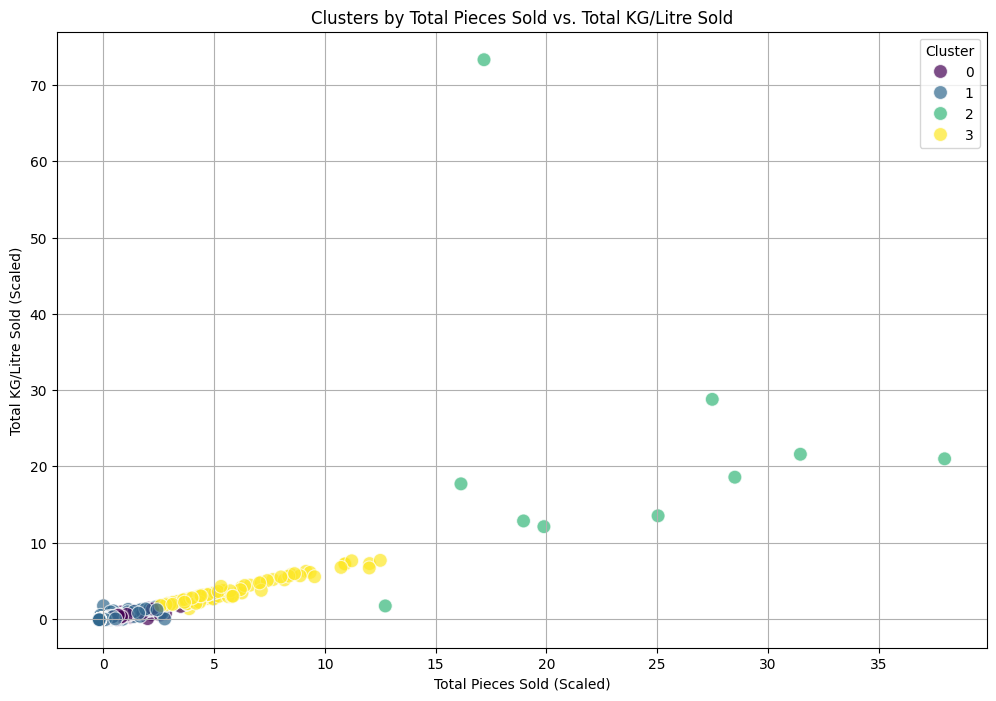

In [20]:
# Visualize clusters based on some key features
plt.figure(figsize=(12, 8))
sns.scatterplot(data=outlet_features_scaled, x='Total_Sales', y='Unique_Products', hue='Cluster', palette='viridis', s=100, alpha=0.7)
plt.title('Clusters by Total Sales vs. Unique Products')
plt.xlabel('Total Sales (Scaled)')
plt.ylabel('Unique Products (Scaled)')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=outlet_features_scaled, x='Total_Pieces_Sold', y='Total_KGLitre_Sold', hue='Cluster', palette='viridis', s=100, alpha=0.7)
plt.title('Clusters by Total Pieces Sold vs. Total KG/Litre Sold')
plt.xlabel('Total Pieces Sold (Scaled)')
plt.ylabel('Total KG/Litre Sold (Scaled)')
plt.grid(True)
plt.show()

### Evaluating K-Means Clustering Performance

To evaluate the quality of the K-Means clustering with 4 segments, I will calculate the Silhouette Score and the Davies-Bouldin Index. These metrics help assess the compactness and separation of the clusters.

*   **Silhouette Score:** Measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The score ranges from -1 to 1, where a high value indicates well-separated clusters.
*   **Davies-Bouldin Index:** Measures the ratio of within-cluster scatter to between-cluster separation. A lower Davies-Bouldin Index relates to a model with better separation between the clusters.

In [22]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate Silhouette Score
silhouette_avg = silhouette_score(X, outlet_features_scaled['Cluster'])
print(f"Silhouette Score: {silhouette_avg:.3f}")

# Calculate Davies-Bouldin Index
davies_bouldin_idx = davies_bouldin_score(X, outlet_features_scaled['Cluster'])
print(f"Davies-Bouldin Index: {davies_bouldin_idx:.3f}")

Silhouette Score: 0.572
Davies-Bouldin Index: 0.636


### Evaluating K-Means Clustering Performance

To evaluate the quality of the K-Means clustering with 4 segments, I will calculate the Silhouette Score and the Davies-Bouldin Index. These metrics help assess the compactness and separation of the clusters.

*   **Silhouette Score:** Measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The score ranges from -1 to 1, where a high value indicates well-separated clusters.
*   **Davies-Bouldin Index:** Measures the ratio of within-cluster scatter to between-cluster separation. A lower Davies-Bouldin Index relates to a model with better separation between the clusters.

### Exploring Hierarchical Clustering

Since we've evaluated K-Means, let's now explore Hierarchical Clustering. Hierarchical clustering builds a hierarchy of clusters. We'll use a dendrogram to visualize this hierarchy and help us decide on the number of clusters.

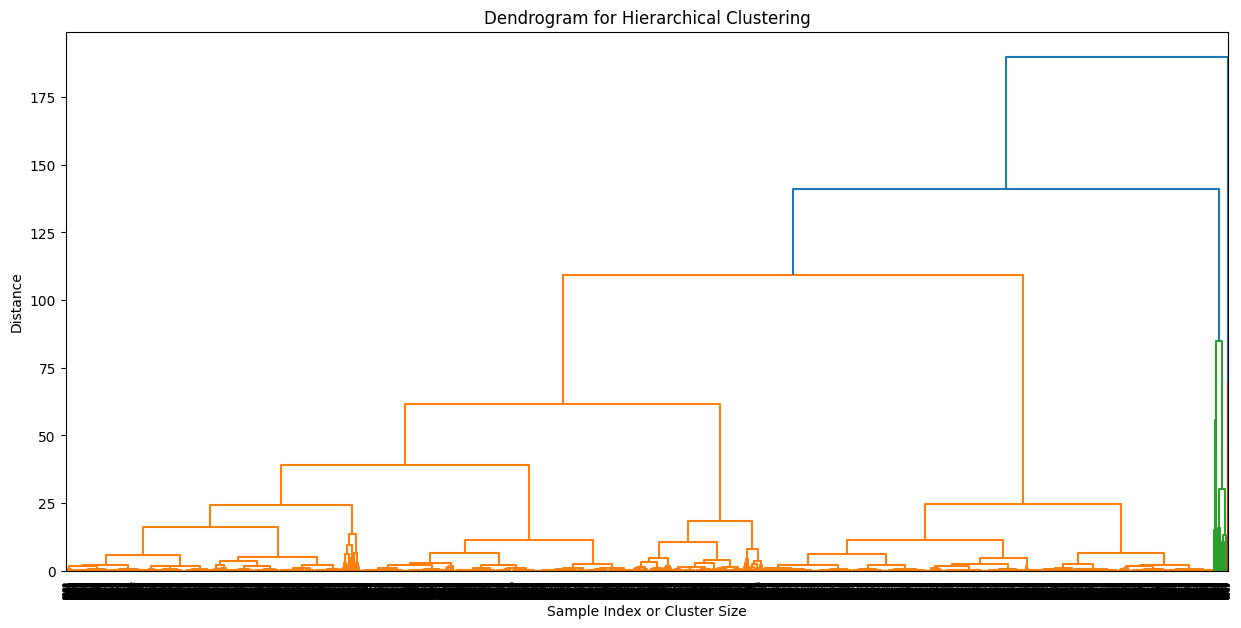

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate the linkage matrix
linked = linkage(X, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.show()

### Applying Hierarchical Clustering

Based on the dendrogram, we can choose a number of clusters. For consistency with K-Means and the user's initial request, we will again target 4 clusters. We'll use `AgglomerativeClustering`.

In [28]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering with 4 clusters
hierarchical_cluster = AgglomerativeClustering(n_clusters=4, linkage='ward')
outlet_features_scaled['Hierarchical_Cluster'] = hierarchical_cluster.fit_predict(X)

print("Outlet Features DataFrame with Hierarchical Cluster Labels:")
display(outlet_features_scaled.head())

Outlet Features DataFrame with Hierarchical Cluster Labels:


,Outlet_ID,Total_Sales,Unique_Products,Avg_Sales_Per_Product,Total_Pieces_Sold,Total_KGLitre_Sold,Outlet_Class,Cluster,Hierarchical_Cluster
0,389,-0.131313,-0.817644,-0.091493,-0.166614,-0.099418,D,1,3
1,390,-0.041918,2.179256,-0.088540,0.014206,-0.015616,D,0,2
2,391,-0.098296,0.500992,-0.085482,-0.112368,-0.068325,A,0,2
3,392,0.784273,2.419008,0.174628,0.803548,0.900888,D,0,2
4,393,-0.014796,3.018388,-0.085416,0.111126,-0.006209,D,0,2


### Analyzing Hierarchical Clusters

Let's analyze the characteristics of these newly formed hierarchical clusters, similar to how we analyzed the K-Means clusters.

In [29]:
# Merge hierarchical cluster labels back to the original (unscaled) outlet_features
outlet_features['Hierarchical_Cluster'] = outlet_features_scaled['Hierarchical_Cluster']

# Calculate the mean of original features for each hierarchical cluster
hierarchical_cluster_analysis = outlet_features.groupby('Hierarchical_Cluster')[numerical_features].mean()
print("Mean of features per hierarchical cluster (unscaled):")
display(hierarchical_cluster_analysis)

# Analyze Outlet_Class distribution within each hierarchical cluster
print("\nOutlet_Class distribution per hierarchical cluster:")
hierarchical_cluster_outlet_class_distribution = outlet_features.groupby('Hierarchical_Cluster')['Outlet_Class'].value_counts(normalize=True).unstack(fill_value=0)
display(hierarchical_cluster_outlet_class_distribution)

Mean of features per hierarchical cluster (unscaled):


,Total_Sales,Unique_Products,Avg_Sales_Per_Product,Total_Pieces_Sold,Total_KGLitre_Sold
Hierarchical_Cluster,,,,,
0,3.097645e+06,13.563636,156006.395362,23622.545455,17365.050000
1,1.820838e+07,11.800000,941039.548579,119062.200000,160073.528000
2,5.502568e+04,19.103894,1848.431866,620.317023,343.943441
3,1.234129e+04,5.675798,1379.092245,131.624468,76.712904



Outlet_Class distribution per hierarchical cluster:


Outlet_Class,(blank),A,B,C,D
Hierarchical_Cluster,,,,,
0,0.000000,0.836364,0.045455,0.036364,0.081818
1,0.000000,0.800000,0.000000,0.200000,0.000000
2,0.000000,0.108201,0.157133,0.423846,0.310820
3,0.000266,0.053457,0.094415,0.371809,0.480053


### Evaluating Hierarchical Clustering Performance

Now, let's calculate the Silhouette Score and Davies-Bouldin Index for the Hierarchical Clustering to compare it with K-Means.

In [30]:
# Calculate Silhouette Score for Hierarchical Clustering
hierarchical_silhouette_avg = silhouette_score(X, outlet_features_scaled['Hierarchical_Cluster'])
print(f"Hierarchical Clustering Silhouette Score: {hierarchical_silhouette_avg:.3f}")

# Calculate Davies-Bouldin Index for Hierarchical Clustering
hierarchical_davies_bouldin_idx = davies_bouldin_score(X, outlet_features_scaled['Hierarchical_Cluster'])
print(f"Hierarchical Clustering Davies-Bouldin Index: {hierarchical_davies_bouldin_idx:.3f}")

Hierarchical Clustering Silhouette Score: 0.512
Hierarchical Clustering Davies-Bouldin Index: 0.610


### Analyzing Hierarchical Clusters

Let's analyze the characteristics of these newly formed hierarchical clusters, similar to how we analyzed the K-Means clusters.

In [31]:
# Merge hierarchical cluster labels back to the original (unscaled) outlet_features
outlet_features['Hierarchical_Cluster'] = outlet_features_scaled['Hierarchical_Cluster']

# Calculate the mean of original features for each hierarchical cluster
hierarchical_cluster_analysis = outlet_features.groupby('Hierarchical_Cluster')[numerical_features].mean()
print("Mean of features per hierarchical cluster (unscaled):")
display(hierarchical_cluster_analysis)

# Analyze Outlet_Class distribution within each hierarchical cluster
print("\nOutlet_Class distribution per hierarchical cluster:")
hierarchical_cluster_outlet_class_distribution = outlet_features.groupby('Hierarchical_Cluster')['Outlet_Class'].value_counts(normalize=True).unstack(fill_value=0)
display(hierarchical_cluster_outlet_class_distribution)

Mean of features per hierarchical cluster (unscaled):


,Total_Sales,Unique_Products,Avg_Sales_Per_Product,Total_Pieces_Sold,Total_KGLitre_Sold
Hierarchical_Cluster,,,,,
0,3.097645e+06,13.563636,156006.395362,23622.545455,17365.050000
1,1.820838e+07,11.800000,941039.548579,119062.200000,160073.528000
2,5.502568e+04,19.103894,1848.431866,620.317023,343.943441
3,1.234129e+04,5.675798,1379.092245,131.624468,76.712904



Outlet_Class distribution per hierarchical cluster:


Outlet_Class,(blank),A,B,C,D
Hierarchical_Cluster,,,,,
0,0.000000,0.836364,0.045455,0.036364,0.081818
1,0.000000,0.800000,0.000000,0.200000,0.000000
2,0.000000,0.108201,0.157133,0.423846,0.310820
3,0.000266,0.053457,0.094415,0.371809,0.480053


### Evaluating Hierarchical Clustering Performance

Now, let's calculate the Silhouette Score and Davies-Bouldin Index for the Hierarchical Clustering to compare it with K-Means.

In [32]:
# Calculate Silhouette Score for Hierarchical Clustering
hierarchical_silhouette_avg = silhouette_score(X, outlet_features_scaled['Hierarchical_Cluster'])
print(f"Hierarchical Clustering Silhouette Score: {hierarchical_silhouette_avg:.3f}")

# Calculate Davies-Bouldin Index for Hierarchical Clustering
hierarchical_davies_bouldin_idx = davies_bouldin_score(X, outlet_features_scaled['Hierarchical_Cluster'])
print(f"Hierarchical Clustering Davies-Bouldin Index: {hierarchical_davies_bouldin_idx:.3f}")

Hierarchical Clustering Silhouette Score: 0.512
Hierarchical Clustering Davies-Bouldin Index: 0.610


In [21]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate Silhouette Score
silhouette_avg = silhouette_score(X, outlet_features_scaled['Cluster'])
print(f"Silhouette Score: {silhouette_avg:.3f}")

# Calculate Davies-Bouldin Index
davies_bouldin_idx = davies_bouldin_score(X, outlet_features_scaled['Cluster'])
print(f"Davies-Bouldin Index: {davies_bouldin_idx:.3f}")

Silhouette Score: 0.572
Davies-Bouldin Index: 0.636


In [34]:
import pandas as pd

# Remove the '(blank)' column if it exists and is all zeros (or negligible values)
# Assuming `cluster_outlet_class_distribution` is already defined from previous steps

# Check if '(blank)' column exists
if '(blank)' in cluster_outlet_class_distribution.columns:
    # Drop the column
    cluster_outlet_class_distribution_cleaned = cluster_outlet_class_distribution.drop(columns=['(blank)'], errors='ignore')
else:
    cluster_outlet_class_distribution_cleaned = cluster_outlet_class_distribution.copy()

# Display cleaned distribution for verification
print("Outlet_Class distribution per cluster (blank removed):")
display(cluster_outlet_class_distribution_cleaned)

# Prepare data for the markdown table
cluster_definitions = {}
for i in range(4):
    cluster_data = cluster_analysis.loc[i]
    cluster_class_dist = cluster_outlet_class_distribution_cleaned.loc[i].apply(lambda x: f'{x*100:.2f}%').to_dict()

    # Convert float values to formatted strings
    total_sales = f"{cluster_data['Total_Sales']:.2f}"
    unique_products = f"{cluster_data['Unique_Products']:.2f}"
    avg_sales_per_product = f"{cluster_data['Avg_Sales_Per_Product']:.2f}"
    total_pieces_sold = f"{cluster_data['Total_Pieces_Sold']:.2f}"
    total_kglitre_sold = f"{cluster_data['Total_KGLitre_Sold']:.2f}"

    # Sort class distribution for consistent display, and format
    sorted_class_dist = sorted(cluster_class_dist.items(), key=lambda item: item[1], reverse=True)
    class_dist_str = ', '.join([f"{k} (`{v}`)" for k, v in sorted_class_dist])

    cluster_definitions[i] = {
        'statistical_behavior':
            f"**Total Sales:** `{total_sales}` <br> "
            f"**Unique Products:** `{unique_products}` <br> "
            f"**Avg Sales Per Product:** `{avg_sales_per_product}` <br> "
            f"**Total Pieces Sold:** `{total_pieces_sold}` <br> "
            f"**Total KG/Litre Sold:** `{total_kglitre_sold}` <br> "
            f"**Outlet Class Distribution:** {class_dist_str}"
    }

# Manually define behavioral definitions based on the analysis (as done in the speak section)
cluster_definitions[0]['key_characteristics'] = "**Mid-Value, Balanced Outlets:** These are general-purpose outlets with moderate overall sales and a reasonable variety of products. They show a balanced performance across most metrics and are less specialized than other clusters. Diverse in Outlet Class, with 'C' and 'D' being prominent."
cluster_definitions[1]['key_characteristics'] = "**Lower-Value, High Average Sales Efficiency, Emerging/Smaller Outlets:** These outlets have lower total sales and fewer unique products, suggesting a smaller scale of operation. However, their `Avg_Sales_Per_Product` is notably higher than Cluster 0, indicating they might focus on selling fewer, higher-value items or achieve good efficiency per product sold. Predominantly 'D' class, indicating smaller or less active outlets."
cluster_definitions[2]['key_characteristics'] = "**Premium, Ultra-High Volume/Value, Niche Specialists:** This is a distinct, small cluster representing an extreme, high-impact segment. They exhibit astronomical total sales and average sales per product, signifying either very large volume transactions or extremely high-value products. While not having the most unique products, their financial impact is immense. Overwhelmingly dominated by 'A' class outlets, suggesting flagship stores or key accounts."
cluster_definitions[3]['key_characteristics'] = "**High-Value, High-Volume Performers, Elite Outlets:** These outlets are strong performers with high total sales, a significant number of unique products, and very high total pieces and KG/Litre sold. Their `Avg_Sales_Per_Product` is also very high, reflecting a combination of high volume and value. Heavily skewed towards 'A' class outlets, indicating top-tier retail partners or major accounts."


# Print the markdown table
print("\n### K-Means Cluster Behavior Definitions:\n")
print("| Cluster | Key Characteristics & Behavioral Definition | Statistical/Mathematical Behavior (Mean Values) |")
print("|---|---|---|")
for i in range(4):
    print(f"| **Cluster {i}** | {cluster_definitions[i]['key_characteristics']} | {cluster_definitions[i]['statistical_behavior']} |")


Outlet_Class distribution per cluster (blank removed):


Outlet_Class,A,B,C,D
Cluster,,,,
0,0.117693,0.173526,0.435387,0.273394
1,0.068816,0.105218,0.381002,0.444791
2,0.800000,0.000000,0.100000,0.100000
3,0.835294,0.035294,0.035294,0.094118



### K-Means Cluster Behavior Definitions:

| Cluster | Key Characteristics & Behavioral Definition | Statistical/Mathematical Behavior (Mean Values) |
|---|---|---|
| **Cluster 0** | **Mid-Value, Balanced Outlets:** These are general-purpose outlets with moderate overall sales and a reasonable variety of products. They show a balanced performance across most metrics and are less specialized than other clusters. Diverse in Outlet Class, with 'C' and 'D' being prominent. | **Total Sales:** `63350.95` <br> **Unique Products:** `22.38` <br> **Avg Sales Per Product:** `1586.17` <br> **Total Pieces Sold:** `733.26` <br> **Total KG/Litre Sold:** `396.93` <br> **Outlet Class Distribution:** C (`43.54%`), D (`27.34%`), B (`17.35%`), A (`11.77%`) |
| **Cluster 1** | **Lower-Value, High Average Sales Efficiency, Emerging/Smaller Outlets:** These outlets have lower total sales and fewer unique products, suggesting a smaller scale of operation. However, their `Avg_Sales_Per_Product` is notably hig

In [35]:
import pandas as pd

# Ensure `outlet_features` contains the 'Cluster' column from K-Means
# If it doesn't, we need to add it again, assuming 'Cluster' is still in outlet_features_scaled
if 'Cluster' not in outlet_features.columns:
    outlet_features['Cluster'] = outlet_features_scaled['Cluster']

# Select only 'Outlet_ID' and 'Cluster' from outlet_features to merge
# This avoids redundant columns if outlet_features was already merged with original df
cluster_map = outlet_features[['Outlet_ID', 'Cluster']]

# Merge the cluster labels back to the original DataFrame
df_merged = pd.merge(df, cluster_map, on='Outlet_ID', how='left')

print("Original DataFrame head with new 'Cluster' column:")
display(df_merged.head())
print(f"\nShape of the merged DataFrame: {df_merged.shape}")

Original DataFrame head with new 'Cluster' column:


,Month,Region,ASM,ASO,Distributor_Type,Super_code,Super_name,Distributor_Code,Distributor_Name,Distributor_Area,...,Route_Name,Category,Subcategory,SKU_Code,SKU_Name,Pieces,KG/Litre,Sales in Rs.,YearMonth,Cluster
0,2025-12-01,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,"Centralkolkata,Rajakatra Market",Oils,Ricebran Oil,HTRBO1027,Ricebran Oil 825 gm Pch,6,4.95,786.00,2025-12,0
1,2025-12-01,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,"Centralkolkata,Rajakatra Market",Oils,Ricebran Oil,HTRBO1031,Ricebran Oil 730 gm Pch,12,8.76,1437.36,2025-12,0
2,2025-12-01,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,"Centralkolkata,Rajakatra Market",Oils,Sunflower Oil,HTSFO1018,Sunflower Oil 825 gm Pch,6,4.95,877.50,2025-12,0
3,2025-12-01,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,"Centralkolkata,Rajakatra Market",Oils,Sunflower Oil,HTSFO1030,Sunflower Oil 780 gm Pch (12 pc),12,9.36,1693.68,2025-12,0
4,2025-12-01,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,Rajakatra Market,Oils,Ricebran Oil,HTRBO1031,Ricebran Oil 730 gm Pch,6,4.38,718.68,2025-12,1



Shape of the merged DataFrame: (214880, 27)


Now that the cluster information is integrated into your main sales data, you can perform various analytics, such as:

1.  **Analyzing Sales Performance per Cluster:** Understand which segments contribute most to total sales, KG/Litre, or pieces sold.
2.  **Product Preferences per Cluster:** Identify which product categories or SKUs are more popular within specific customer segments.
3.  **Regional Performance per Cluster:** See how different clusters are distributed geographically or perform in different regions.
4.  **Campaign Effectiveness:** Tailor marketing campaigns to specific segments and analyze their effectiveness.
5.  **Targeted Strategies:** Develop specific strategies for each segment (e.g., premium offerings for high-value clusters, promotional bundles for lower-value clusters).

Let's look at some examples.

In [36]:
# Example 1: Total Sales by Cluster
sales_by_cluster = df_merged.groupby('Cluster')['Sales in Rs.'].sum().sort_values(ascending=False)
print("\nTotal Sales by Cluster:")
display(sales_by_cluster)

# Example 2: Average Sales per Transaction by Cluster
avg_sales_per_transaction = df_merged.groupby('Cluster')['Sales in Rs.'].mean().sort_values(ascending=False)
print("\nAverage Sales per Transaction by Cluster:")
display(avg_sales_per_transaction)

# Example 3: Most Popular Categories per Cluster
# Get top 3 categories for each cluster
print("\nTop 3 Categories per Cluster:")
for cluster_id in sorted(df_merged['Cluster'].unique()):
    cluster_data = df_merged[df_merged['Cluster'] == cluster_id]
    top_categories = cluster_data['Category'].value_counts().head(3)
    print(f"\nCluster {cluster_id}:")
    display(top_categories)


Total Sales by Cluster:


,Sales in Rs.
Cluster,
3,2.679250e+08
0,2.416839e+08
1,1.477794e+08
2,1.401669e+08



Average Sales per Transaction by Cluster:


,Sales in Rs.
Cluster,
2,648920.793657
3,107041.535649
1,2165.741267
0,1679.223132



Top 3 Categories per Cluster:

Cluster 0:


...

,count
Category,
Oils,43380
Staples,9710
Pure Spices,7495



Cluster 2:


,count
Category,
Oils,179
Staples,20
Pure Spices,9



Cluster 3:


,count
Category,
Oils,1961
Pure Spices,203
Staples,138


In [40]:
cluster_names_map = {
    0: 'Mid-Value, Balanced Outlets',
    1: 'Lower-Value, High Average Sales Efficiency, Emerging/Smaller Outlets',
    2: 'Premium, Ultra-High Volume/Value, Niche Specialists',
    3: 'High-Value, High-Volume Performers, Elite Outlets'
}

df_merged['Segment_Name'] = df_merged['Cluster'].map(cluster_names_map)

print("DataFrame head with new 'Segment_Name' column:")
display(df_merged.head())

print("\nValue counts for the new 'Segment_Name' column:")
display(df_merged['Segment_Name'].value_counts())

DataFrame head with new 'Segment_Name' column:


,Month,Region,ASM,ASO,Distributor_Type,Super_code,Super_name,Distributor_Code,Distributor_Name,Distributor_Area,...,Category,Subcategory,SKU_Code,SKU_Name,Pieces,KG/Litre,Sales in Rs.,YearMonth,Cluster,Segment_Name
0,2025-12-01,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,Oils,Ricebran Oil,HTRBO1027,Ricebran Oil 825 gm Pch,6,4.95,786.00,2025-12,0,"Mid-Value, Balanced Outlets"
1,2025-12-01,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,Oils,Ricebran Oil,HTRBO1031,Ricebran Oil 730 gm Pch,12,8.76,1437.36,2025-12,0,"Mid-Value, Balanced Outlets"
2,2025-12-01,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,Oils,Sunflower Oil,HTSFO1018,Sunflower Oil 825 gm Pch,6,4.95,877.50,2025-12,0,"Mid-Value, Balanced Outlets"
3,2025-12-01,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,Oils,Sunflower Oil,HTSFO1030,Sunflower Oil 780 gm Pch (12 pc),12,9.36,1693.68,2025-12,0,"Mid-Value, Balanced Outlets"
4,2025-12-01,East 1,Hafiz Mondal,Abhishek Kumar Singh,Distributor,(blank),(blank),103998,M.K. Traders,Central Kolkata,...,Oils,Ricebran Oil,HTRBO1031,Ricebran Oil 730 gm Pch,6,4.38,718.68,2025-12,1,"Lower-Value, High Average Sales Efficiency, Em..."



Value counts for the new 'Segment_Name' column:


,count
Segment_Name,
"Mid-Value, Balanced Outlets",143926
"Lower-Value, High Average Sales Efficiency, Emerging/Smaller Outlets",68235
"High-Value, High-Volume Performers, Elite Outlets",2503
"Premium, Ultra-High Volume/Value, Niche Specialists",216


In [41]:
output_file_path = '/content/Final_data_set_with_segments.csv'
df_merged.to_csv(output_file_path, index=False)
print(f"DataFrame saved to {output_file_path}")

DataFrame saved to /content/Final_data_set_with_segments.csv


These are just a few examples. You can extend this analysis to explore other dimensions, such as `Subcategory`, `SKU_Name`, `Month`, `Region`, `ASM`, or `ASO` in relation to your identified clusters to gain deeper insights into your outlet segments.

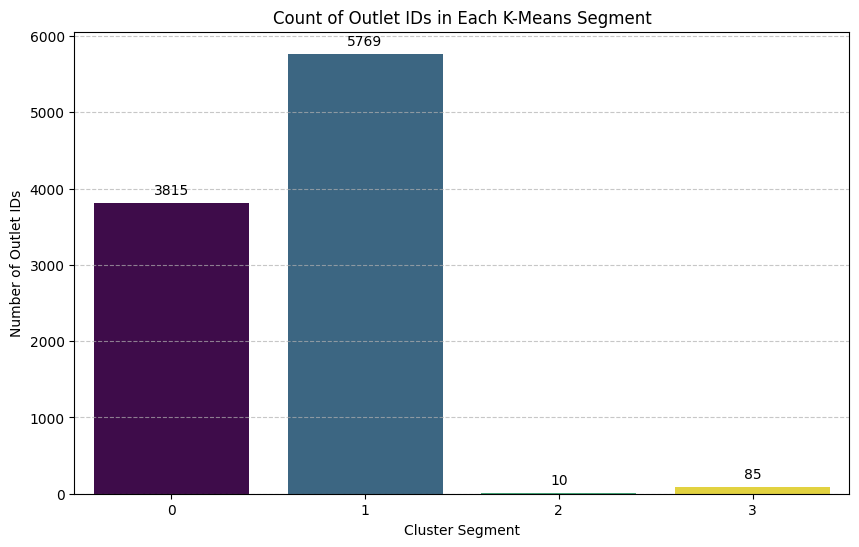

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of outlets in each cluster
cluster_counts = outlet_features['Cluster'].value_counts().sort_index()

# Create a bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis', hue=cluster_counts.index, legend=False)
plt.title('Count of Outlet IDs in Each K-Means Segment')
plt.xlabel('Cluster Segment')
plt.ylabel('Number of Outlet IDs')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()